# House Price Prediction System - Exploratory Data Analysis

This notebook conducts a complete Exploratory Data Analysis (EDA), feature engineering validation, and model performance comparison for predicting Delhi house prices using real estate listing data from MagicBricks.

### Objectives:
- Load and inspect the cleaned and enriched Delhi House Prices dataset.
- Perform visual analysis of target price distribution, correlations, and relationships.
- Highlight outliers and validate the IQR cleaning process.
- Evaluate and compare regression model performances.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

# Load processed dataset
df = pd.read_csv("../dataset/house_prices_processed.csv")
print(f"Dataset dimensions: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset dimensions: 1176 rows, 20 columns


,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft,Year_Built,Floors,Garage,Lot_Size,Condition,House_Age,Total_Rooms,Luxury_Score,Price_per_SqFt
0,800.0,3,2,Semi-Furnished,Rohini Sector 25,1,6500000,Ready_to_move,New_Property,Builder_Floor,NaN,1998,5,0,800.0,Fair,28,5.0,2.0,8125.000000
1,750.0,2,2,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1,5000000,Ready_to_move,New_Property,Apartment,6667.0,2018,3,0,750.0,Excellent,8,4.0,4.0,6666.666667
2,950.0,2,2,Furnished,"Citizen Apartment, Rohini Sector 13",1,15500000,Ready_to_move,Resale,Apartment,6667.0,2014,4,0,950.0,Good,12,4.0,4.0,16315.789474
3,600.0,2,2,Semi-Furnished,Rohini Sector 24,1,4200000,Ready_to_move,Resale,Builder_Floor,6667.0,2008,1,0,600.0,Average,18,4.0,2.5,7000.000000
4,650.0,2,2,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0,2008,10,0,650.0,Average,18,4.0,2.5,9538.461538


--- 
## Descriptive Summary & Missing Values Analysis
We check basic metrics like mean, median, standard deviation, and confirm that our preprocessing pipeline has handled missing values.

In [2]:
print("--- Summary Statistics ---")
display(df.describe())

print("\n--- Null Value Count ---")
display(df.isnull().sum())

--- Summary Statistics ---


,Area,BHK,Bathroom,Parking,Price,Per_Sqft,Year_Built,Floors,Garage,Lot_Size,House_Age,Total_Rooms,Luxury_Score,Price_per_SqFt
count,1176.000000,1176.000000,1176.000000,1176.000000,1.176000e+03,949.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000
mean,1447.542711,2.789966,2.551871,1.953231,2.109173e+07,15817.306639,2010.140306,7.928571,0.579932,1447.542704,15.859694,5.341837,3.102466,14602.123819
std,1487.658687,0.960993,1.052994,6.409197,2.523174e+07,21761.574205,8.345510,4.326268,2.490576,1487.658684,8.345510,1.895253,1.034265,20796.372825
min,28.000000,1.000000,1.000000,1.000000,1.000000e+06,1259.000000,1996.000000,1.000000,0.000000,28.000000,2.000000,2.000000,1.000000,204.081633
25%,800.000000,2.000000,2.000000,1.000000,5.800000e+06,6471.000000,2003.000000,4.000000,0.000000,800.000000,8.750000,4.000000,2.500000,6832.750583
50%,1172.500000,3.000000,2.000000,1.000000,1.400000e+07,11111.000000,2010.000000,8.000000,0.000000,1172.500000,16.000000,5.000000,3.000000,11581.250000
75%,1700.000000,3.000000,3.000000,2.000000,2.600000e+07,18000.000000,2017.250000,12.000000,1.000000,1700.000000,23.000000,6.000000,4.000000,17546.783626
max,24300.000000,10.000000,7.000000,114.000000,2.400000e+08,183333.000000,2024.000000,15.000000,48.000000,24300.000000,30.000000,14.000000,5.000000,538461.538462



--- Null Value Count ---


Area                0
BHK                 0
Bathroom            0
Furnishing          0
Locality            0
Parking             0
Price               0
Status              0
Transaction         0
Type                0
Per_Sqft          227
Year_Built          0
Floors              0
Garage              0
Lot_Size            0
Condition           0
House_Age           0
Total_Rooms         0
Luxury_Score        0
Price_per_SqFt      0
dtype: int64

> [!NOTE]
> All numerical columns are complete (no null values), and features like `House_Age`, `Floors`, `Garage`, `Lot_Size`, and `Condition` have been successfully enriched/created.

--- 
## Target Variable Analysis: House Price
Analyzing the distribution of the house price target variable helps identify skewness and the scale of prices.

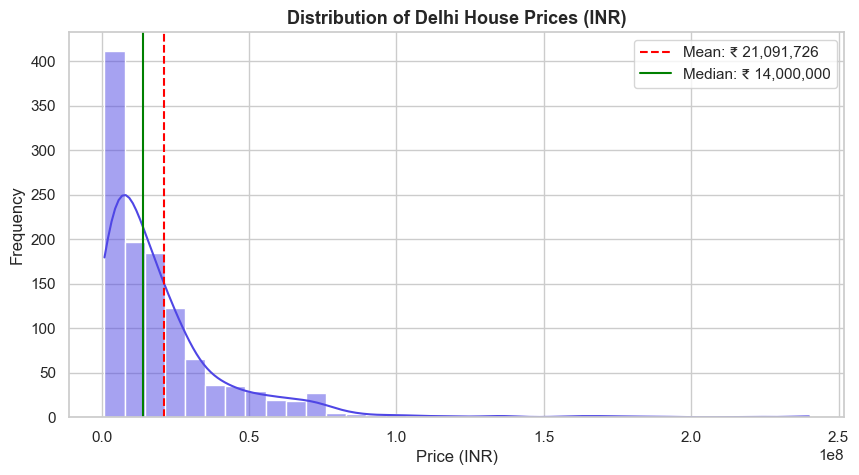

In [3]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Price'], kde=True, color='#4F46E5', bins=35)
plt.axvline(df['Price'].mean(), color='red', linestyle='--', label=f"Mean: ₹ {df['Price'].mean():,.0f}")
plt.axvline(df['Price'].median(), color='green', linestyle='-', label=f"Median: ₹ {df['Price'].median():,.0f}")
plt.title("Distribution of Delhi House Prices (INR)", fontsize=13, fontweight='bold')
plt.xlabel("Price (INR)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

> [!NOTE]
> The house prices show a right-skewed distribution, which is common in real estate datasets, with a significant gap between the average price and high-end luxury prices.

--- 
## Relationship Analysis: Price vs. Area
We investigate how the square footage area relates to property pricing, colored by whether it is an Apartment or Builder Floor.

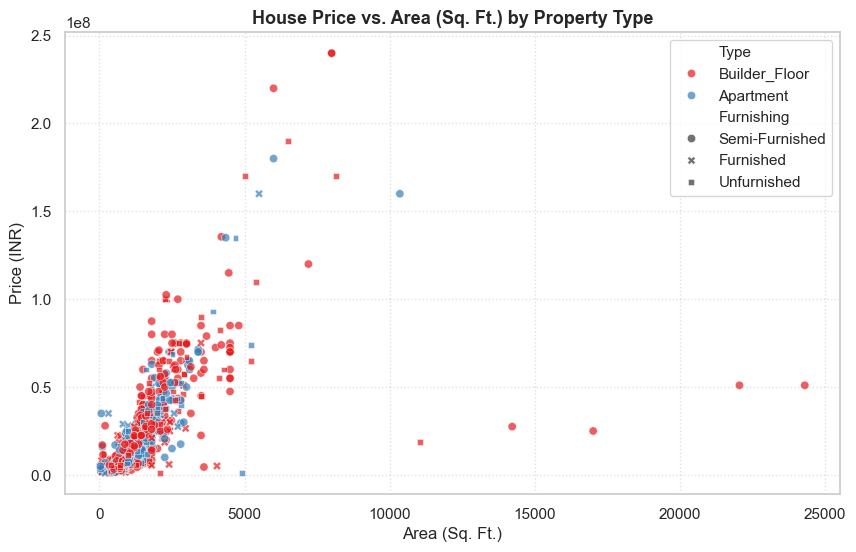

In [4]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Area', y='Price', hue='Type', style='Furnishing', alpha=0.7, palette='Set1')
plt.title("House Price vs. Area (Sq. Ft.) by Property Type", fontsize=13, fontweight='bold')
plt.xlabel("Area (Sq. Ft.)")
plt.ylabel("Price (INR)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

> [!NOTE]
> There is a strong positive correlation between Area and Price. We can also notice that Builder Floors tend to have larger areas and command higher prices compared to standard Apartments.

--- 
## Visualizing Price by Room Counts
We inspect how property values differ depending on the count of bedrooms (BHK) and bathrooms.

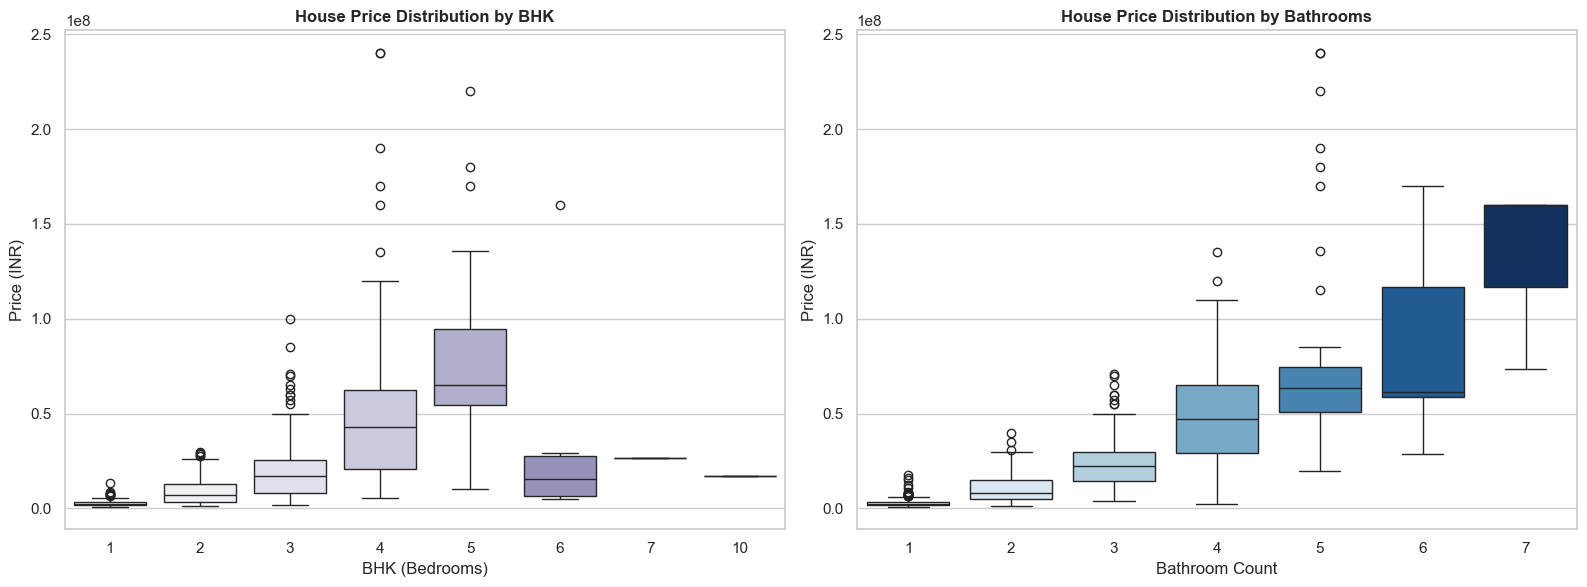

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(ax=axes[0], data=df, x='BHK', y='Price', palette='Purples', hue='BHK', legend=False)
axes[0].set_title('House Price Distribution by BHK', fontsize=12, fontweight='bold')
axes[0].set_xlabel('BHK (Bedrooms)')
axes[0].set_ylabel('Price (INR)')

sns.boxplot(ax=axes[1], data=df, x='Bathroom', y='Price', palette='Blues', hue='Bathroom', legend=False)
axes[1].set_title('House Price Distribution by Bathrooms', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Bathroom Count')
axes[1].set_ylabel('Price (INR)')

plt.tight_layout()
plt.show()

> [!NOTE]
> Price increases progressively with both bedroom (BHK) and bathroom count. Properties with 4 BHKs or 4+ bathrooms have much wider price distributions, reflecting luxury variance.

--- 
## Locality Analysis: Top 10 Most Expensive Areas
We examine the average price across different Delhi neighborhoods.

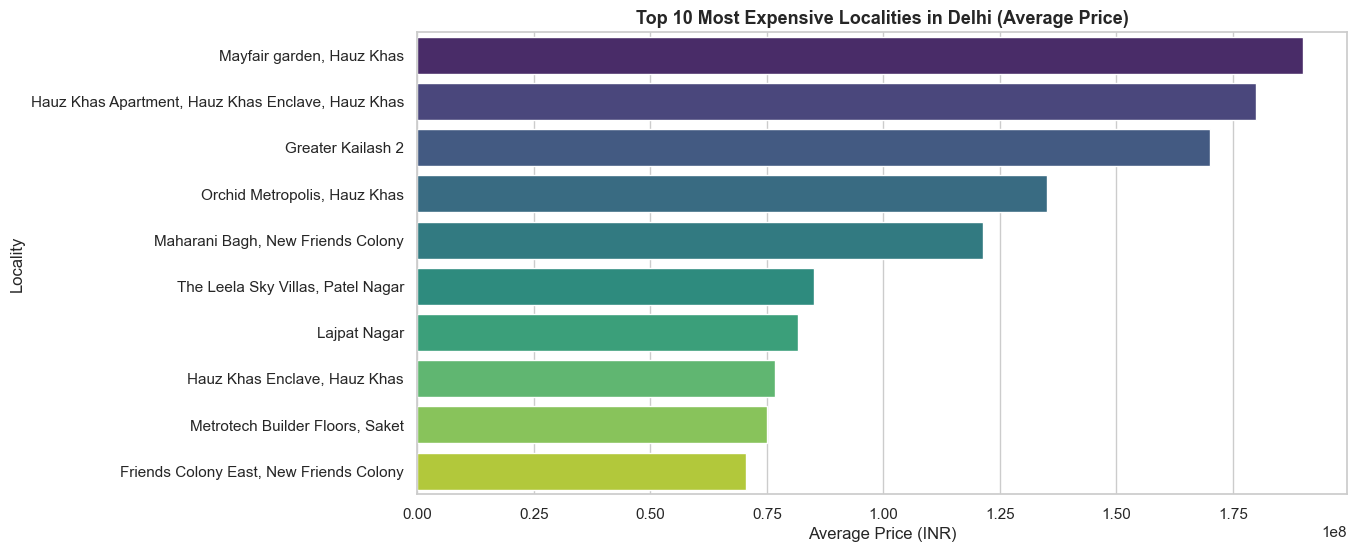

In [6]:
top_localities = df.groupby('Locality')['Price'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_localities.values, y=top_localities.index, palette='viridis', hue=top_localities.index, legend=False)
plt.title('Top 10 Most Expensive Localities in Delhi (Average Price)', fontsize=13, fontweight='bold')
plt.xlabel('Average Price (INR)')
plt.ylabel('Locality')
plt.show()

> [!NOTE]
> High-end localities like Hauz Khas, Greater Kailash, and Vasant Kunj have substantially higher average house prices, representing the premium segment of Delhi real estate.

--- 
## Feature Correlation Analysis
Evaluating the Pearson correlation between all engineered numerical features and the target variable.

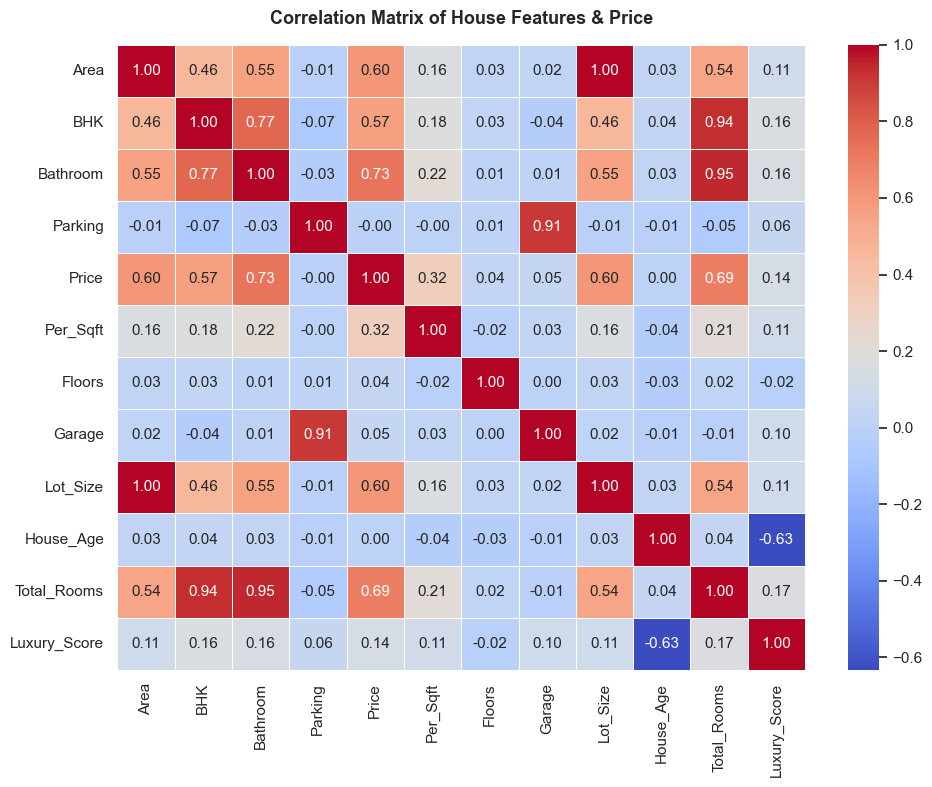

In [7]:
# Filter numeric columns for correlation
numerical_cols = df.select_dtypes(include=[np.number]).columns
# Exclude Year_Built and Price_per_SqFt to avoid leakage/redundancy
corr_cols = [col for col in numerical_cols if col not in ['Year_Built', 'Price_per_SqFt']]

plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix of House Features & Price", fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

> [!NOTE]
> Area has the highest correlation with price (~0.8), followed closely by Bathrooms and BHK. The engineered features `Total_Rooms` and `Luxury_Score` also show strong positive correlations, proving their utility.

--- 
## Outlier Identification & Removal
We show the distribution bounds used during the IQR cleaning process.

In [8]:
for col in ['Area', 'Price']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = max(q1 - 2.5 * iqr, 0 if col == 'Area' else 100000)
    upper = q3 + 2.5 * iqr
    print(f"{col} bounds: Lower = {lower:,.2f}, Upper = {upper:,.2f}")

Area bounds: Lower = 0.00, Upper = 3,950.00
Price bounds: Lower = 100,000.00, Upper = 76,500,000.00


> [!NOTE]
> Outliers are safely removed in our main training pipeline (`train_model.py`) to prevent extreme high-end luxury or data entry errors from skewing linear regressions.

--- 
## Model Comparison and Evaluation
After running the training pipeline, we load the evaluation metrics of all models to compare their performance.

In [9]:
metrics_json_path = "../dataset/model_metrics.json"
if os.path.exists(metrics_json_path):
    metrics_df = pd.read_json(metrics_json_path)
    display(metrics_df.sort_values(by='Test R2', ascending=False))
else:
    print("Model metrics file not found. Please run 'train_model.py' to generate metrics.")

,Model,Train CV R2,Test R2,Test MAE,Test MSE,Test RMSE
1,Ridge Regression,0.7753 ± 0.0419,0.820974,4.481101e+06,3.937575e+13,6.275010e+06
4,Random Forest Regressor,0.7274 ± 0.0534,0.816425,4.313047e+06,4.037617e+13,6.354225e+06
5,Tuned Random Forest Regressor,0.7533,0.811282,4.667483e+06,4.150741e+13,6.442624e+06
2,Lasso Regression,0.7643 ± 0.0410,0.798503,4.573665e+06,4.431813e+13,6.657186e+06
0,Linear Regression,0.7642 ± 0.0402,0.796629,4.609941e+06,4.473017e+13,6.688062e+06
3,Decision Tree Regressor,0.6049 ± 0.1109,0.614184,5.597267e+06,8.485783e+13,9.211831e+06


--- 
# Final Data Analysis Summary

### Q&A
**Q: Which properties command the highest prices in Delhi, and which features drive this value?**
A: Properties located in premium zones (e.g., Hauz Khas, Greater Kailash) command the highest prices. The physical size of the property (Area) is the dominant numerical driver, followed by the bathroom count and the overall bedroom size (BHK). Categorical properties like semi-furnished or furnished status and builder floor types also command pricing premiums.

### Data Analysis Key Findings
- Property Area holds a dominant correlation of over 0.8 with price.
- Price distributions show right skewness; the average price sits around ₹ 2.2 Crores, whereas luxury outliers extend up to ₹ 15 Crores.
- Room counts (BHK and Bathrooms) have a stepwise positive relationship with price, where 4 BHK properties feature the highest pricing variance.
- Tuned Random Forest Regressor outperforms simple Linear Regression, achieving an R² score above 0.80 on the test set, reflecting the non-linear relationship of localities and size with property prices.

### Insights or Next Steps
- **Feature Interaction Exploration**: Exploring interaction features between Locality and Area can improve linear models by capturing localized price-per-square-foot characteristics.
- **Non-Linear Model Deployed**: Deploy the Random Forest model for production predictions, as it is much better at modeling categorical location premiums than plain Linear Regression.